# Decision Tree - Chẩn đoán bệnh Alzheimer

Notebook này sử dụng thuật toán **Decision Tree (Cây quyết định)** để phân loại và dự đoán bệnh Alzheimer dựa trên dữ liệu đã được tiền xử lý.



## 1. Import thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_theme(context='notebook', palette='muted', style='darkgrid')

RANDOM_STATE = 42
CV = 5

print("Đã import thư viện thành công!")


Đã import thư viện thành công!


## 2. Đọc dữ liệu đã qua tiền xử lý

In [2]:
# Đọc dữ liệu đã được tiền xử lý từ file CSV
df = pd.read_csv('./data/alzheimers_preprocessed.csv')

print(f"Kích thước dữ liệu: {df.shape}")
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("\n5 dòng đầu tiên:")
display(df.head())

Kích thước dữ liệu: (2149, 36)
Số dòng: 2149, Số cột: 36

5 dòng đầu tiên:


,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_0,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,-0.212368,0,2,-0.655225,0,0.565923,0.492525,-1.253593,1.119918,0,0,1,1,0,0,0.298159,-1.014750,0.403677,-1.572661,-1.114429,-0.648199,0.779037,0.497506,0,0,-1.104434,0,0,0,1,0,0,True,False,False,False
1,1.567757,0,0,-0.114751,0,-0.954895,0.945093,-1.538442,0.056836,0,0,0,0,0,0,-0.742572,-1.469595,0.140248,1.593119,0.845730,0.650721,0.680297,0.704907,0,0,-0.810601,0,0,0,0,1,0,True,False,False,False
2,-0.212368,0,1,-1.366428,0,1.653006,1.023896,-1.088855,1.487380,1,0,0,0,0,0,-1.359301,1.486898,1.386812,0.668569,0.445615,-1.418585,-0.859222,0.281813,0,0,0.724491,0,1,0,1,0,0,False,False,False,True
3,-0.101111,1,1,0.851625,1,0.376930,1.227995,0.839804,0.760833,0,0,0,0,0,0,-0.626935,1.430043,-1.542715,-1.360103,0.388780,0.483468,-0.088723,1.343346,0,1,0.508044,0,0,0,0,0,0,True,False,False,False
4,1.567757,0,0,-0.961607,0,1.461793,0.486696,-1.443293,-0.824566,0,0,0,0,0,0,-1.552029,1.543754,0.291653,-0.725756,-0.111924,0.617060,-0.143712,0.333665,0,0,-1.684679,0,0,1,1,0,0,True,False,False,False


In [3]:
# Kiểm tra thông tin tổng quát về dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   float64
 1   Gender                     2149 non-null   int64  
 2   EducationLevel             2149 non-null   int64  
 3   BMI                        2149 non-null   float64
 4   Smoking                    2149 non-null   int64  
 5   AlcoholConsumption         2149 non-null   float64
 6   PhysicalActivity           2149 non-null   float64
 7   DietQuality                2149 non-null   float64
 8   SleepQuality               2149 non-null   float64
 9   FamilyHistoryAlzheimers    2149 non-null   int64  
 10  CardiovascularDisease      2149 non-null   int64  
 11  Diabetes                   2149 non-null   int64  
 12  Depression                 2149 non-null   int64  
 13  HeadInjury                 2149 non-null   int64  
 14  Hyp

In [4]:
# Kiểm tra phân phối của biến mục tiêu (Diagnosis)
print("Phân phối nhãn Diagnosis:")
print(df['Diagnosis'].value_counts())
print(f"\nTỷ lệ:")
print(df['Diagnosis'].value_counts(normalize=True) * 100)

Phân phối nhãn Diagnosis:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Tỷ lệ:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


## 3. Tách Features (X) và Target (y)

In [5]:
# Tách biến độc lập (X - features) và biến mục tiêu (y - target)
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print(f"Shape của X (features): {X.shape}")
print(f"Shape của y (target): {y.shape}")
print(f"\nCác features trong X:")
print(X.columns.tolist())

Shape của X (features): (2149, 35)
Shape của y (target): (2149,)

Các features trong X:
['Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Ethnicity_0', 'Ethnicity_1', 'Ethnicity_2', 'Ethnicity_3']


## 4. Chia tập Train/Test

In [6]:
# Chia tập dữ liệu thành tập huấn luyện (80%) và tập kiểm thử (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Đảm bảo tỷ lệ các class giữ nguyên trong train/test
)

print(f"Tập huấn luyện (Train): {X_train.shape[0]} mẫu")
print(f"Tập kiểm thử (Test): {X_test.shape[0]} mẫu")
print(f"\nPhân phối nhãn trong tập train:")
print(y_train.value_counts())
print(f"\nPhân phối nhãn trong tập test:")
print(y_test.value_counts())

Tập huấn luyện (Train): 1719 mẫu
Tập kiểm thử (Test): 430 mẫu

Phân phối nhãn trong tập train:
Diagnosis
0    1111
1     608
Name: count, dtype: int64

Phân phối nhãn trong tập test:
Diagnosis
0    278
1    152
Name: count, dtype: int64


## 5. Khởi tạo và Huấn luyện mô hình Decision Tree

In [7]:
# Khởi tạo mô hình Decision Tree Classifier
# max_depth=4: Giới hạn độ sâu của cây để tránh overfitting và dễ diễn giải
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    criterion='gini'  # Có thể thử 'entropy' để so sánh
)

dt_classifier.fit(X_train, y_train)

print(f"\nĐộ sâu của cây (Tree depth): {dt_classifier.get_depth()}")
print(f"Số lượng lá (Number of leaves): {dt_classifier.get_n_leaves()}")


Độ sâu của cây (Tree depth): 4
Số lượng lá (Number of leaves): 16


## 6. Dự đoán trên tập Test

In [8]:
# Sử dụng mô hình để dự đoán trên tập kiểm thử
y_pred = dt_classifier.predict(X_test)
y_pred_proba = dt_classifier.predict_proba(X_test)

print(f"\nSố lượng dự đoán: {len(y_pred)}")
print(f"Dự đoán đầu tiên (5 mẫu): {y_pred[:5]}")
print(f"Nhãn thực tế (5 mẫu đầu): {y_test.values[:5]}")


Số lượng dự đoán: 430
Dự đoán đầu tiên (5 mẫu): [1 0 1 1 1]
Nhãn thực tế (5 mẫu đầu): [1 1 1 1 1]


## 7. Đánh giá chất lượng mô hình

In [9]:
# Tính độ chính xác tổng thể
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print(f" Độ chính xác tổng thể (Accuracy): {accuracy * 100:.2f}%")
print("="*50)

 Độ chính xác tổng thể (Accuracy): 92.33%


In [10]:
# Báo cáo phân loại chi tiết (Classification Report)
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Không bệnh', 'Có bệnh']))


Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

  Không bệnh       0.96      0.92      0.94       278
     Có bệnh       0.87      0.92      0.89       152

    accuracy                           0.92       430
   macro avg       0.91      0.92      0.92       430
weighted avg       0.93      0.92      0.92       430



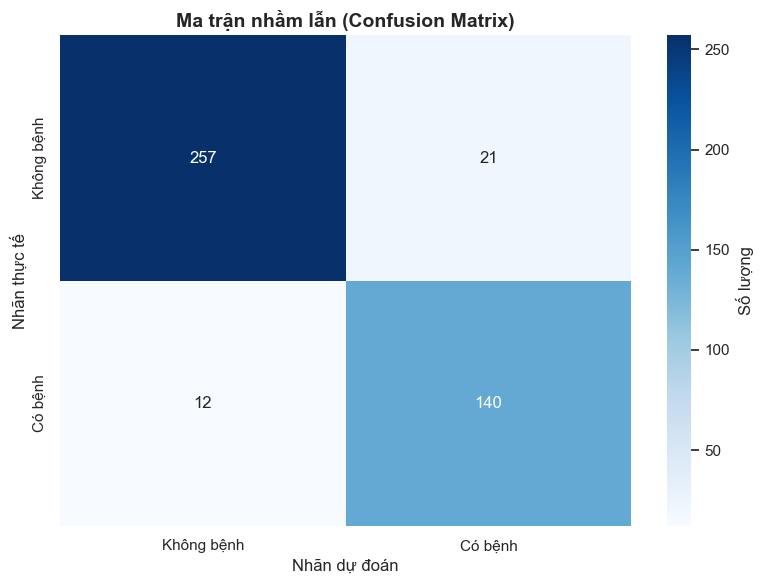


True Negatives (TN): 257
False Positives (FP): 21
False Negatives (FN): 12
True Positives (TP): 140


In [11]:
# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không bệnh', 'Có bệnh'],
            yticklabels=['Không bệnh', 'Có bệnh'],
            cbar_kws={'label': 'Số lượng'})
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn thực tế', fontsize=12)
plt.xlabel('Nhãn dự đoán', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (TN): {cm[0][0]}")
print(f"False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]}")
print(f"True Positives (TP): {cm[1][1]}")

## 8. Kiểm tra Overfitting

In [12]:
# Dự đoán trên tập train để so sánh với tập test
y_train_pred = dt_classifier.predict(X_train)

# Tính độ chính xác trên cả 2 tập
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("KIỂM TRA OVERFITTING")
print(f"Độ chính xác trên tập TRAIN: {train_accuracy * 100:.2f}%")
print(f"Độ chính xác trên tập TEST:  {test_accuracy * 100:.2f}%")
print(f"Chênh lệch (Train - Test):   {(train_accuracy - test_accuracy) * 100:.2f}%")

# Phân tích kết quả
if (train_accuracy - test_accuracy) > 0.1:  # Chênh lệch > 10%
    print("\nMô hình có dấu hiệu Overfitting")
else:
    print("\nMô hình KHÔNG bị overfitting đáng kể")

KIỂM TRA OVERFITTING
Độ chính xác trên tập TRAIN: 94.30%
Độ chính xác trên tập TEST:  92.33%
Chênh lệch (Train - Test):   1.97%

Mô hình KHÔNG bị overfitting đáng kể


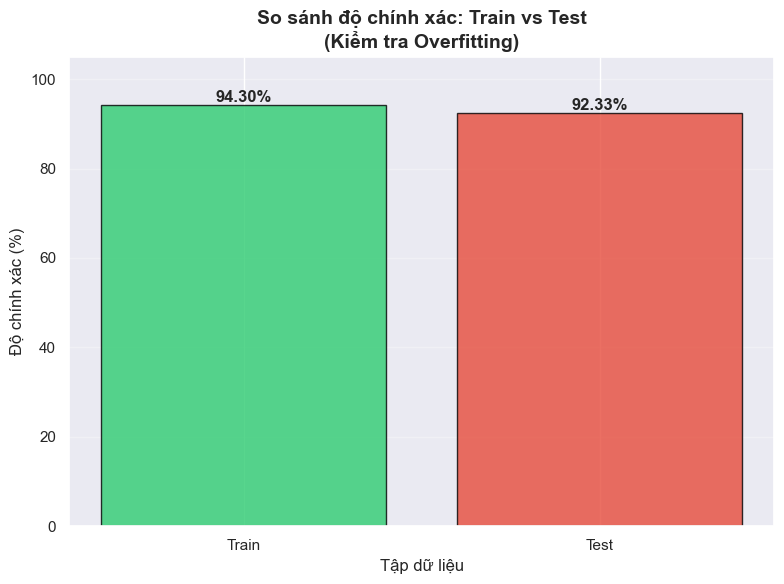

In [13]:
# Biểu đồ so sánh Train vs Test Accuracy
comparison_data = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Accuracy': [train_accuracy * 100, test_accuracy * 100]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(comparison_data['Dataset'], comparison_data['Accuracy'], 
               color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')

# Thêm giá trị lên trên cột
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Tập dữ liệu', fontsize=12)
plt.ylabel('Độ chính xác (%)', fontsize=12)
plt.title('So sánh độ chính xác: Train vs Test\n(Kiểm tra Overfitting)', 
          fontsize=14, fontweight='bold')
plt.ylim([0, 105])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Thử nghiệm với các độ sâu khác nhau để tối ưu hóa

In [14]:
# Thử nghiệm với nhiều giá trị max_depth khác nhau
max_depths = [2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
train_scores = []
test_scores = []

print("Thử nghiệm với các độ sâu khác nhau của cây...\n")

for depth in max_depths:
    # Huấn luyện mô hình với max_depth khác nhau
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='gini')
    dt_temp.fit(X_train, y_train)
    
    # Tính accuracy
    train_acc = dt_temp.score(X_train, y_train)
    test_acc = dt_temp.score(X_test, y_test)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    depth_str = str(depth) if depth is not None else "Không giới hạn"
    print(f"max_depth={depth_str:15s} → Train: {train_acc*100:.2f}%  |  Test: {test_acc*100:.2f}%  |  Gap: {(train_acc-test_acc)*100:.2f}%")


Thử nghiệm với các độ sâu khác nhau của cây...

max_depth=2               → Train: 79.76%  |  Test: 78.37%  |  Gap: 1.38%
max_depth=3               → Train: 89.47%  |  Test: 88.14%  |  Gap: 1.33%
max_depth=4               → Train: 94.30%  |  Test: 92.33%  |  Gap: 1.97%
max_depth=5               → Train: 96.34%  |  Test: 92.79%  |  Gap: 3.54%
max_depth=6               → Train: 96.80%  |  Test: 93.02%  |  Gap: 3.78%
max_depth=7               → Train: 97.61%  |  Test: 91.16%  |  Gap: 6.45%
max_depth=8               → Train: 98.08%  |  Test: 91.16%  |  Gap: 6.92%
max_depth=10              → Train: 98.84%  |  Test: 91.40%  |  Gap: 7.44%
max_depth=15              → Train: 99.83%  |  Test: 89.77%  |  Gap: 10.06%
max_depth=20              → Train: 100.00%  |  Test: 89.77%  |  Gap: 10.23%
max_depth=Không giới hạn  → Train: 100.00%  |  Test: 89.77%  |  Gap: 10.23%


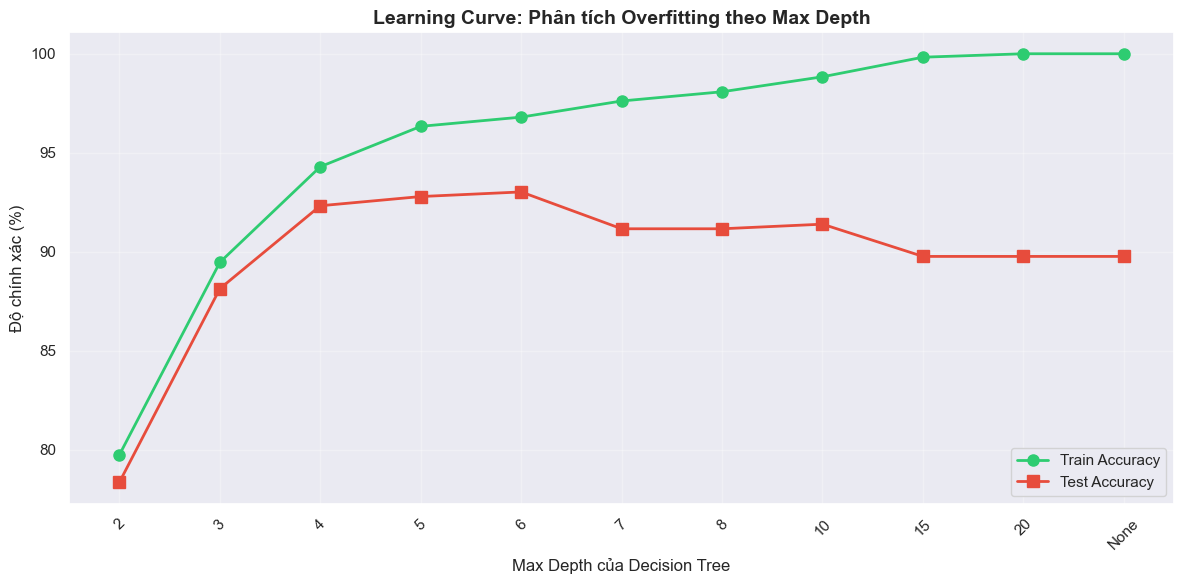


Max_depth tối ưu: 6
Độ chính xác Test tốt nhất: 93.02%


In [15]:
# Vẽ biểu đồ Learning Curve
plt.figure(figsize=(12, 6))

depth_labels = [str(d) if d is not None else "None" for d in max_depths]
x_pos = range(len(max_depths))

plt.plot(x_pos, [s*100 for s in train_scores], 'o-', 
         label='Train Accuracy', linewidth=2, markersize=8, color='#2ecc71')
plt.plot(x_pos, [s*100 for s in test_scores], 's-', 
         label='Test Accuracy', linewidth=2, markersize=8, color='#e74c3c')

plt.xticks(x_pos, depth_labels, rotation=45)
plt.xlabel('Max Depth của Decision Tree', fontsize=12)
plt.ylabel('Độ chính xác (%)', fontsize=12)
plt.title('Learning Curve: Phân tích Overfitting theo Max Depth', 
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tìm max_depth tối ưu
best_idx = np.argmax(test_scores)
best_depth = max_depths[best_idx]
best_test_acc = test_scores[best_idx]
depth_str = str(best_depth) if best_depth is not None else "Không giới hạn"

print(f"\nMax_depth tối ưu: {depth_str}")
print(f"Độ chính xác Test tốt nhất: {best_test_acc*100:.2f}%")

## 9. Phân tích độ quan trọng của các thuộc tính

In [16]:
# Trích xuất mức độ quan trọng của các thuộc tính (Feature Importance)
feature_importances = pd.DataFrame({
    'Thuộc tính': X.columns, 
    'Độ quan trọng': dt_classifier.feature_importances_
}).sort_values(by='Độ quan trọng', ascending=False)

print("\n10 thuộc tính quan trọng nhất:")
print("="*60)
display(feature_importances.head(10))

print(f"\n5 thuộc tính quan trọng nhất:")
for idx, row in feature_importances.head(5).iterrows():
    print(f"  {row['Thuộc tính']}: {row['Độ quan trọng']:.4f} ({row['Độ quan trọng']*100:.2f}%)")


10 thuộc tính quan trọng nhất:


,Thuộc tính,Độ quan trọng
25,ADL,0.242962
21,MMSE,0.240816
22,FunctionalAssessment,0.212848
23,MemoryComplaints,0.173372
24,BehavioralProblems,0.124119
7,DietQuality,0.002990
8,SleepQuality,0.002893
2,EducationLevel,0.000000
1,Gender,0.000000
0,Age,0.000000



5 thuộc tính quan trọng nhất:
  ADL: 0.2430 (24.30%)
  MMSE: 0.2408 (24.08%)
  FunctionalAssessment: 0.2128 (21.28%)
  MemoryComplaints: 0.1734 (17.34%)
  BehavioralProblems: 0.1241 (12.41%)


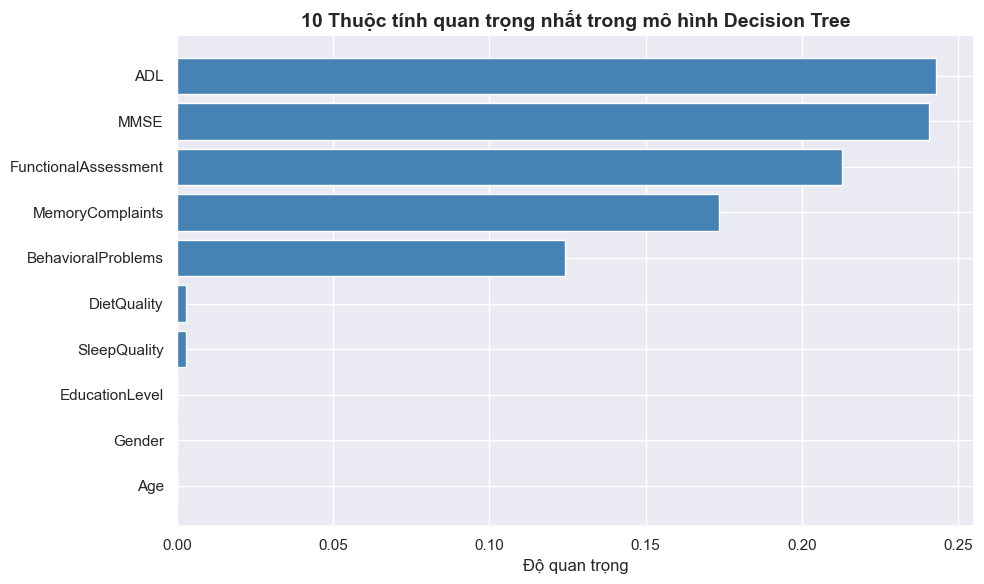

In [17]:
# Biểu đồ Top 10 thuộc tính quan trọng
plt.figure(figsize=(10, 6))
top_10 = feature_importances.head(10)
plt.barh(top_10['Thuộc tính'], top_10['Độ quan trọng'], color='steelblue')
plt.xlabel('Độ quan trọng', fontsize=12)
plt.title('10 Thuộc tính quan trọng nhất trong mô hình Decision Tree', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Trực quan hóa Cây quyết định

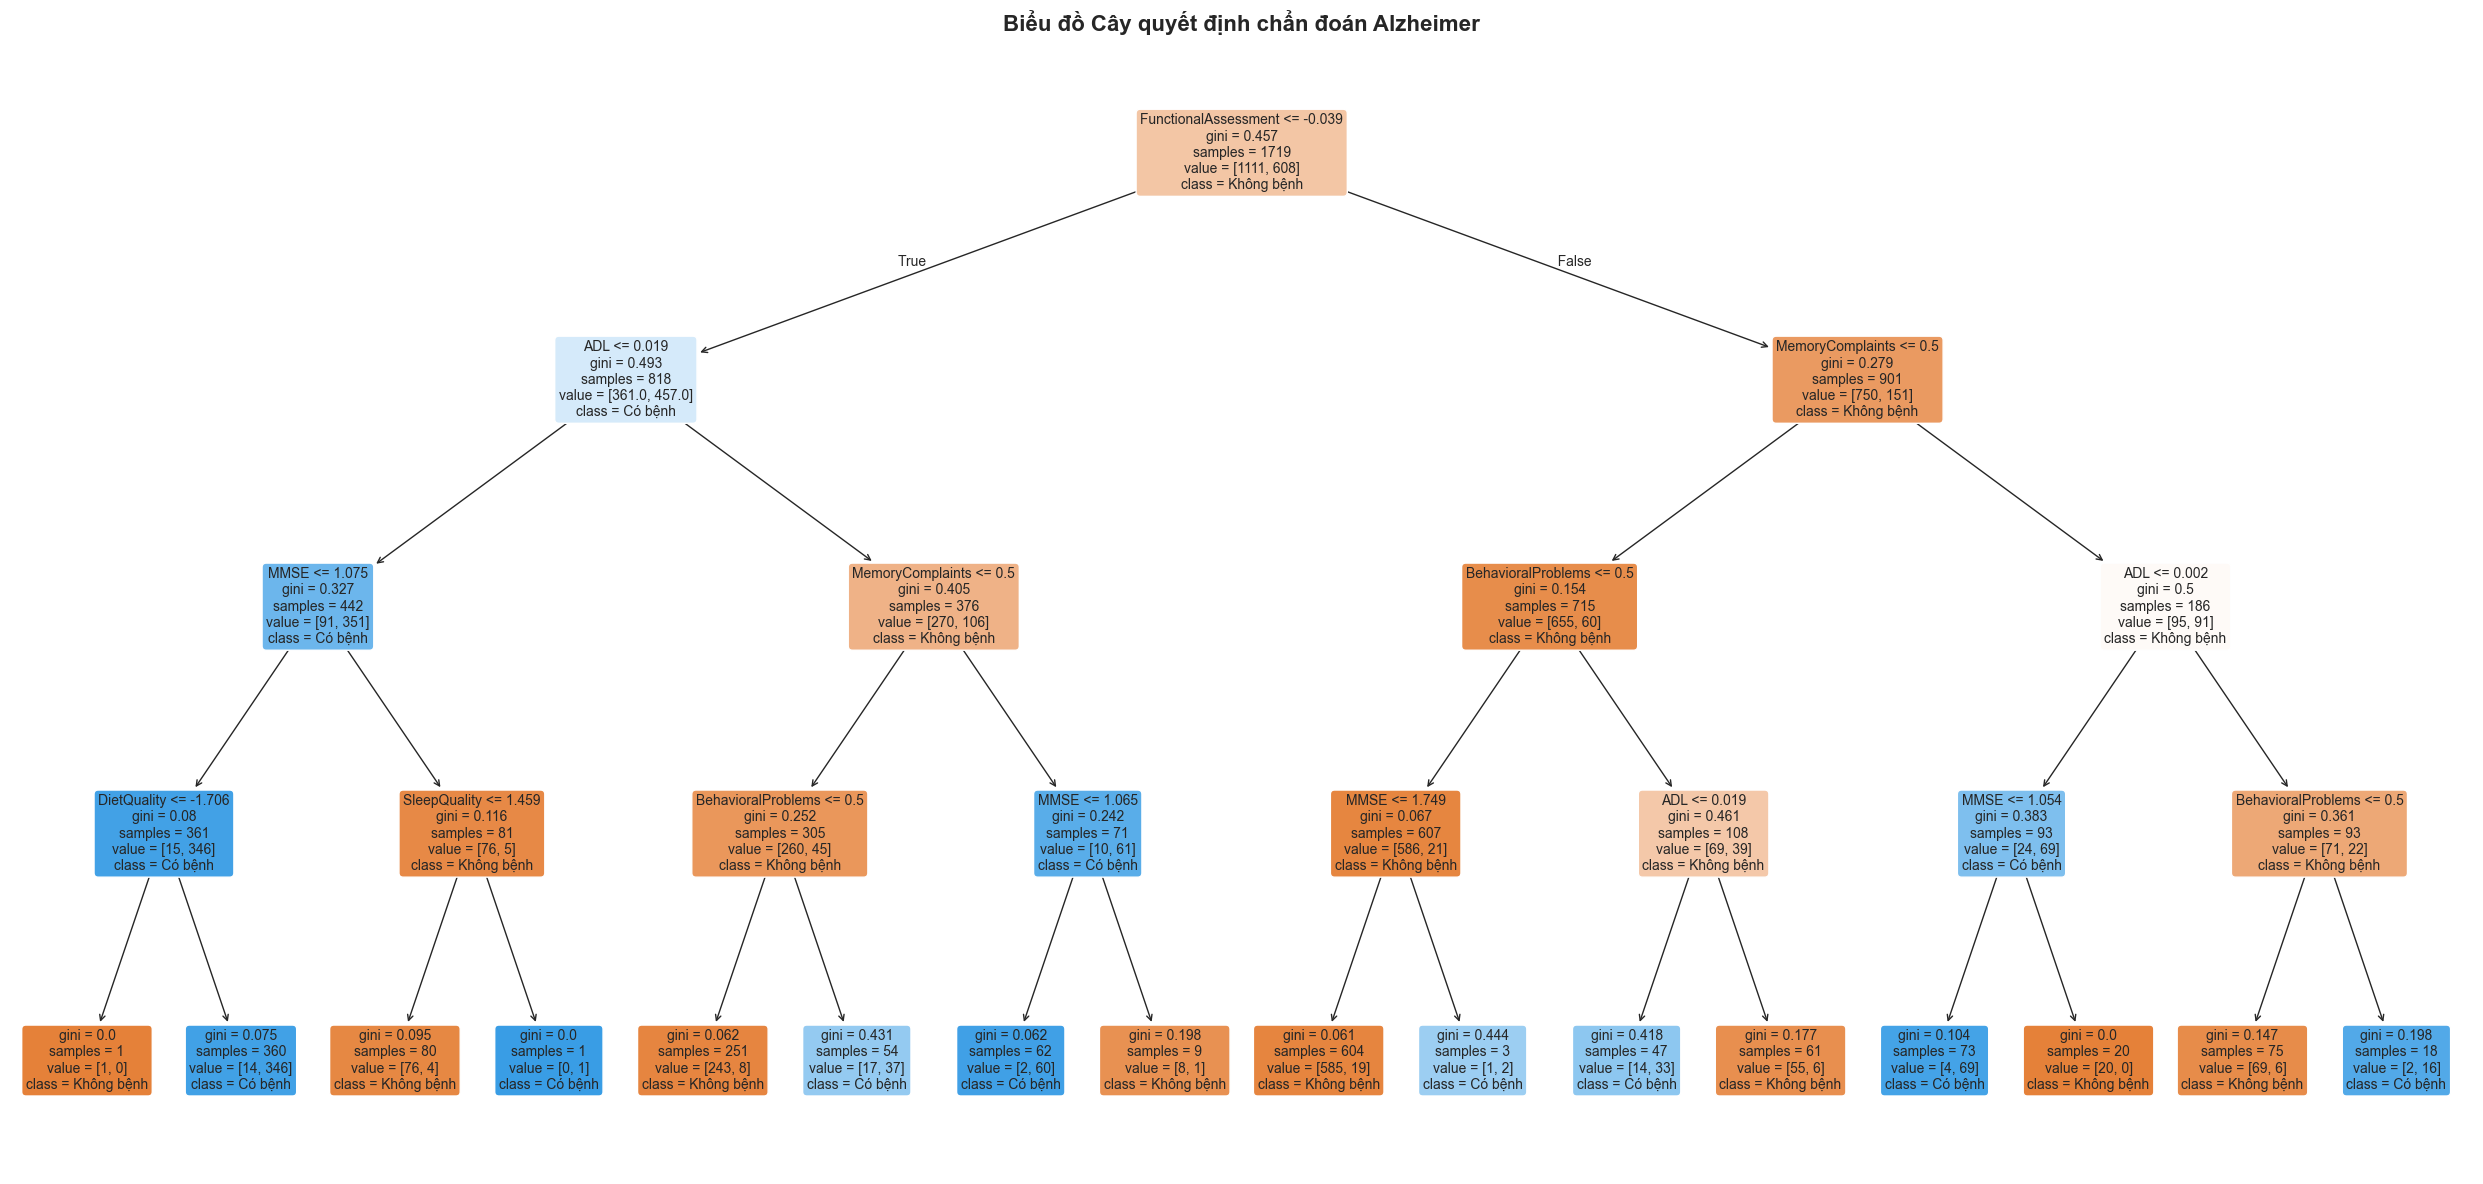

In [18]:
# Vẽ biểu đồ cây quyết định
plt.figure(figsize=(25, 12))
plot_tree(dt_classifier, 
          feature_names=X.columns, 
          class_names=['Không bệnh', 'Có bệnh'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Biểu đồ Cây quyết định chẩn đoán Alzheimer", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Biểu đồ Cây quyết định chẩn đoán Alzheimer')

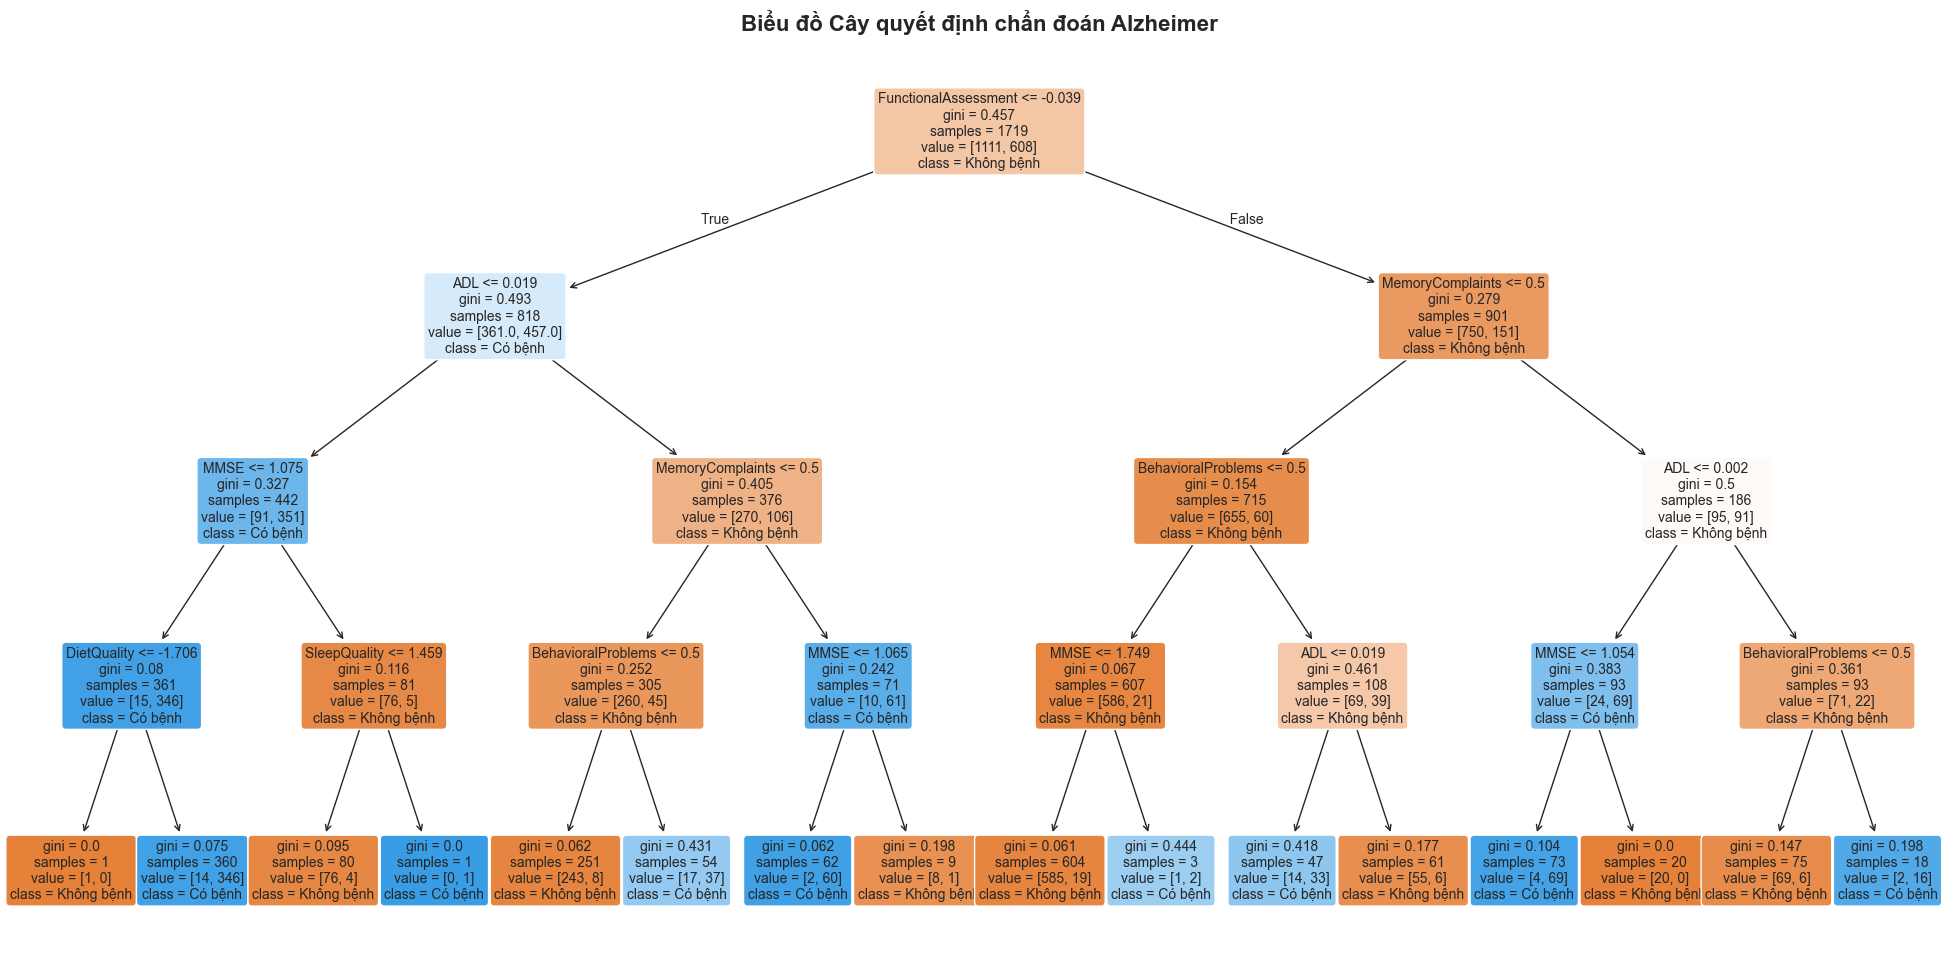

In [19]:
# Lưu biểu đồ cây quyết định ra file
plt.figure(figsize=(25, 12))
plot_tree(dt_classifier, 
          feature_names=X.columns, 
          class_names=['Không bệnh', 'Có bệnh'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Biểu đồ Cây quyết định chẩn đoán Alzheimer", fontsize=16, fontweight='bold')

## 11. So sánh Criterion (Gini vs Entropy) với Cross-Validation

So sánh Criterion với 5-fold Cross-Validation...



Testing criteria:  50%|█████     | 1/2 [00:07<00:07,  7.57s/it]

  GINI: 0.9217 (+/- 0.0304)


Testing criteria: 100%|██████████| 2/2 [00:13<00:00,  6.60s/it]

  ENTROPY: 0.9094 (+/- 0.0317)

Best criterion: gini


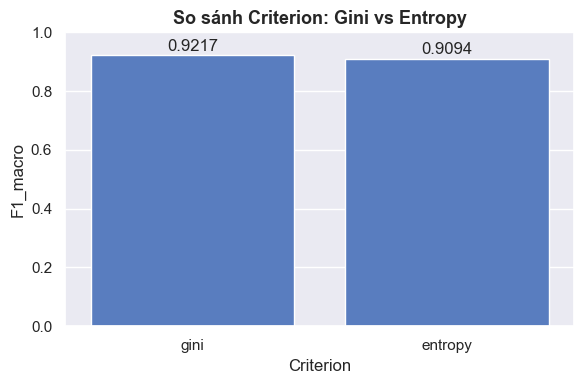

In [20]:
cv = StratifiedKFold(n_splits=CV, shuffle=True, random_state=RANDOM_STATE)
criteria = ['gini', 'entropy']
criterion_results = {}

def add_bar_labels(ax, fmt="{:.4f}", offset=0.005):
    for p in ax.patches:
        value = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, value + offset,
                fmt.format(value), ha='center', va='bottom')

print("So sánh Criterion với 5-fold Cross-Validation...\n")
for crit in tqdm(criteria, desc="Testing criteria"):
    dt = DecisionTreeClassifier(criterion=crit, random_state=RANDOM_STATE, max_depth=4)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    criterion_results[crit] = scores.mean()
    tqdm.write(f"  {crit.upper()}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_criterion = max(criterion_results, key=criterion_results.get)
print(f"\nBest criterion: {best_criterion}")

crit_df = pd.DataFrame(list(criterion_results.items()), columns=['Criterion', 'F1_macro'])
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=crit_df, x='Criterion', y='F1_macro')
plt.title('So sánh Criterion: Gini vs Entropy', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()


## 12. Xử lý Imbalanced Data (SMOTE)

Testing Sampling Techniques



Testing sampling:  50%|█████     | 1/2 [00:04<00:04,  4.82s/it]

  No Sampling: 0.9217 (+/- 0.0304)


Testing sampling: 100%|██████████| 2/2 [00:08<00:00,  4.48s/it]


  SMOTE: 0.9102 (+/- 0.0147)

Best sampling: No Sampling


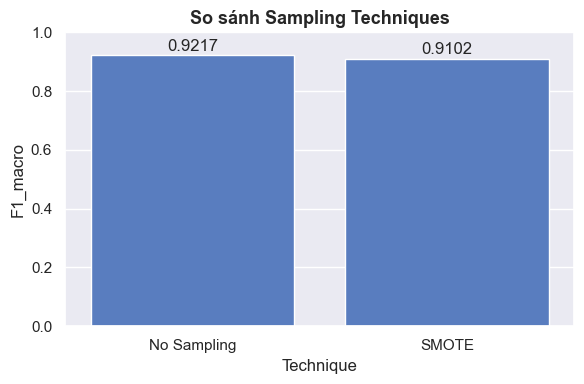

In [21]:
sampling_techniques = {
    'No Sampling': None,
    'SMOTE': SMOTE(random_state=RANDOM_STATE)
}
sampling_results = {}

print("Testing Sampling Techniques\n")
for name, sampler in tqdm(sampling_techniques.items(), desc="Testing sampling"):
    if sampler is None:
        pipe = Pipeline([
            ('dt', DecisionTreeClassifier(criterion=best_criterion, random_state=RANDOM_STATE, max_depth=4))
        ])
    else:
        pipe = ImbPipeline([
            ('sampler', sampler),
            ('dt', DecisionTreeClassifier(criterion=best_criterion, random_state=RANDOM_STATE, max_depth=4))
        ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    sampling_results[name] = scores.mean()
    tqdm.write(f"  {name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_sampling = max(sampling_results, key=sampling_results.get)
best_sampler = sampling_techniques[best_sampling]
print(f"\nBest sampling: {best_sampling}")

samp_df = pd.DataFrame(list(sampling_results.items()), columns=['Technique', 'F1_macro'])
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=samp_df, x='Technique', y='F1_macro')
plt.title('So sánh Sampling Techniques', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()


## 13. So sánh Decision Tree vs Random Forest vs Extra Trees

So sánh Tree-based Models



Testing models:   0%|          | 0/3 [00:00<?, ?it/s]

  Decision Tree: 0.9217 (+/- 0.0304)


Testing models:  67%|██████▋   | 2/3 [00:00<00:00,  2.84it/s]

  Random Forest: 0.7906 (+/- 0.0496)


Testing models: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]


  Extra Trees: 0.5867 (+/- 0.0437)

Best model: Decision Tree


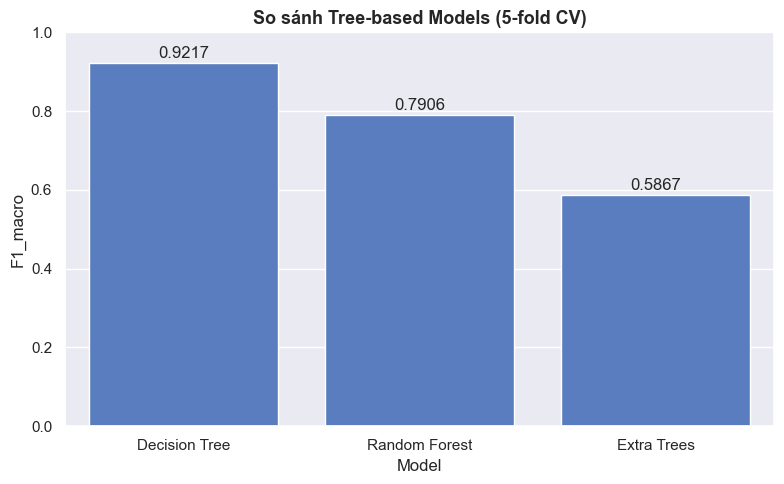

In [22]:
tree_models = {
    'Decision Tree': DecisionTreeClassifier(criterion=best_criterion, random_state=RANDOM_STATE, max_depth=4),
    'Random Forest': RandomForestClassifier(n_estimators=100, criterion=best_criterion, random_state=RANDOM_STATE, max_depth=4, n_jobs=-1),
    'Extra Trees':   ExtraTreesClassifier(n_estimators=100, criterion=best_criterion, random_state=RANDOM_STATE, max_depth=4, n_jobs=-1),
}
tree_results = {}

print("So sánh Tree-based Models\n")
for name, model in tqdm(tree_models.items(), desc="Testing models"):
    if best_sampler is None:
        pipe = Pipeline([('model', model)])
    else:
        pipe = ImbPipeline([('sampler', best_sampler), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    tree_results[name] = scores.mean()
    tqdm.write(f"  {name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_tree_name = max(tree_results, key=tree_results.get)
print(f"\nBest model: {best_tree_name}")

tree_df = pd.DataFrame(list(tree_results.items()), columns=['Model', 'F1_macro'])
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tree_df, x='Model', y='F1_macro')
plt.title('So sánh Tree-based Models (5-fold CV)', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()


## 14. Feature Selection (SelectKBest)

Testing Feature Selection (tổng 35 features)



Testing features:  25%|██▌       | 1/4 [00:00<00:00,  9.53it/s]

  17 features: 0.9241 (+/- 0.0320)


Testing features:  50%|█████     | 2/4 [00:00<00:00,  8.60it/s]

  24 features: 0.9241 (+/- 0.0320)


Testing features:  75%|███████▌  | 3/4 [00:00<00:00,  8.26it/s]

  31 features: 0.9241 (+/- 0.0320)


Testing features: 100%|██████████| 4/4 [00:00<00:00,  8.31it/s]


  35 features: 0.9217 (+/- 0.0304)

Best number of features: 17


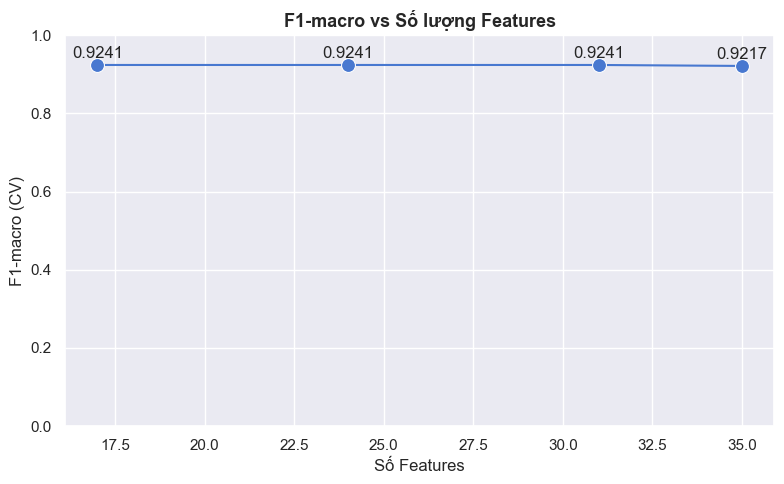

In [23]:
n_total = X_train.shape[1]
feature_counts = [int(n_total*0.5), int(n_total*0.7), int(n_total*0.9), n_total]
feature_results = {}

print(f"Testing Feature Selection (tổng {n_total} features)\n")
for k in tqdm(feature_counts, desc="Testing features"):
    base_model = tree_models[best_tree_name]
    if best_sampler is None:
        pipe = Pipeline([
            ('selector', SelectKBest(score_func=f_classif, k=k)),
            ('model', base_model)
        ])
    else:
        pipe = ImbPipeline([
            ('selector', SelectKBest(score_func=f_classif, k=k)),
            ('sampler', best_sampler),
            ('model', base_model)
        ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    feature_results[k] = scores.mean()
    tqdm.write(f"  {k} features: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_k = max(feature_results, key=feature_results.get)
print(f"\nBest number of features: {best_k}")

feat_df = pd.DataFrame(list(feature_results.items()), columns=['k', 'F1_macro']).sort_values('k')
plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=feat_df, x='k', y='F1_macro', marker='o', markersize=10)
plt.title('F1-macro vs Số lượng Features', fontsize=13, fontweight='bold')
plt.xlabel('Số Features')
plt.ylabel('F1-macro (CV)')
plt.ylim(0, 1)
for xv, yv in zip(feat_df['k'], feat_df['F1_macro']):
    ax.text(xv, yv + 0.01, f'{yv:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 15. GridSearchCV - Tối ưu Hyperparameters

In [24]:
if best_tree_name == 'Decision Tree':
    param_grid = {
        'model__max_depth': [3, 4, 5, 6, 7, 8, 10, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
    }
    base_model = DecisionTreeClassifier(criterion=best_criterion, random_state=RANDOM_STATE)
elif best_tree_name == 'Random Forest':
    param_grid = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [4, 6, 8, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    }
    base_model = RandomForestClassifier(criterion=best_criterion, random_state=RANDOM_STATE, n_jobs=-1)
else:
    param_grid = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [4, 6, 8, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    }
    base_model = ExtraTreesClassifier(criterion=best_criterion, random_state=RANDOM_STATE, n_jobs=-1)

if best_sampler is None:
    pipe_gs = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=best_k)),
        ('model', base_model)
    ])
else:
    pipe_gs = ImbPipeline([
        ('selector', SelectKBest(score_func=f_classif, k=best_k)),
        ('sampler', best_sampler),
        ('model', base_model)
    ])

print(f"GridSearchCV cho {best_tree_name}...\n")
grid = GridSearchCV(pipe_gs, param_grid=param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV F1-macro: {grid.best_score_:.4f}")


GridSearchCV cho Decision Tree...

Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 20}
Best CV F1-macro: 0.9415


## 16. Đánh giá Final Model trên Test Set

           FINAL MODEL EVALUATION
Model    : Decision Tree
Criterion: gini  |  Sampling: No Sampling  |  Features: 17

Test Accuracy : 0.9419
Test F1-macro : 0.9365

Classification Report:
              precision    recall  f1-score   support

  Không bệnh       0.96      0.95      0.95       278
     Có bệnh       0.92      0.92      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.94      0.94      0.94       430



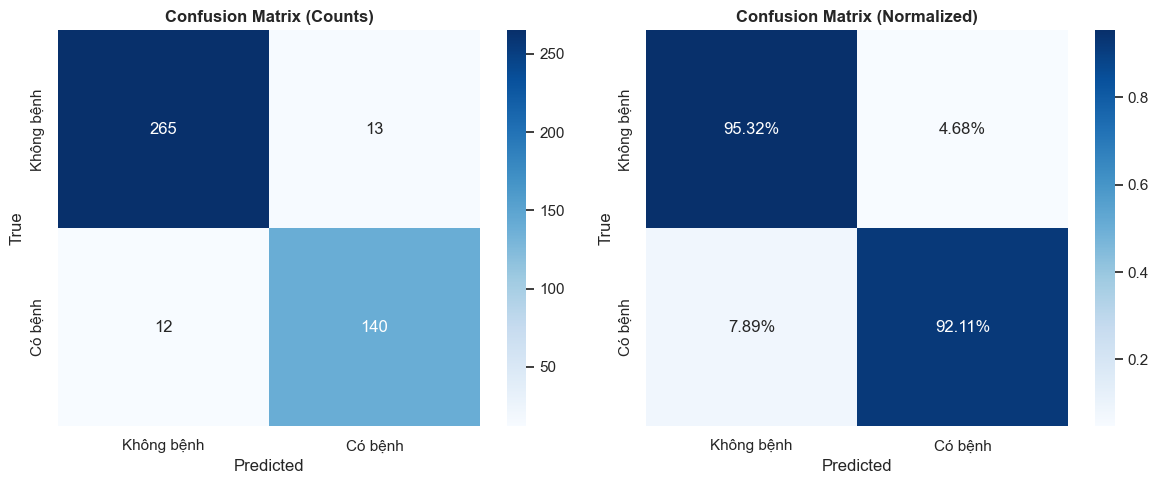

In [25]:
best_model = grid.best_estimator_
y_pred_final = best_model.predict(X_test)

# Accuracy cơ bản (baseline cell 5)
acc_baseline = accuracy_score(y_test, dt_classifier.predict(X_test))
f1_baseline  = f1_score(y_test, dt_classifier.predict(X_test), average='macro')

acc_final = accuracy_score(y_test, y_pred_final)
f1_final  = f1_score(y_test, y_pred_final, average='macro')

print("           FINAL MODEL EVALUATION")
print(f"Model    : {best_tree_name}")
print(f"Criterion: {best_criterion}  |  Sampling: {best_sampling}  |  Features: {best_k}")
print(f"\nTest Accuracy : {acc_final:.4f}")
print(f"Test F1-macro : {f1_final:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Không bệnh', 'Có bệnh']))

# Confusion Matrix đôi
cm_final = confusion_matrix(y_test, y_pred_final)
cm_norm  = cm_final / cm_final.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Không bệnh', 'Có bệnh'],
            yticklabels=['Không bệnh', 'Có bệnh'])
ax[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax[1],
            xticklabels=['Không bệnh', 'Có bệnh'],
            yticklabels=['Không bệnh', 'Có bệnh'])
ax[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()


## 17. Tổng kết kết quả

                      EXPERIMENT SUMMARY
  1. Best Criterion : gini
  2. Best Sampling  : No Sampling
  3. Best Model     : Decision Tree
  4. Best Features  : 17/35

  Baseline  → Accuracy: 0.9233  |  F1-macro: 0.9171
  Optimized → Accuracy: 0.9419  |  F1-macro: 0.9365

  Cải thiện → Accuracy: +1.86%  |  F1-macro: +1.94%

  Best Hyperparameters:
    - model__max_depth: 5
    - model__min_samples_leaf: 4
    - model__min_samples_split: 20


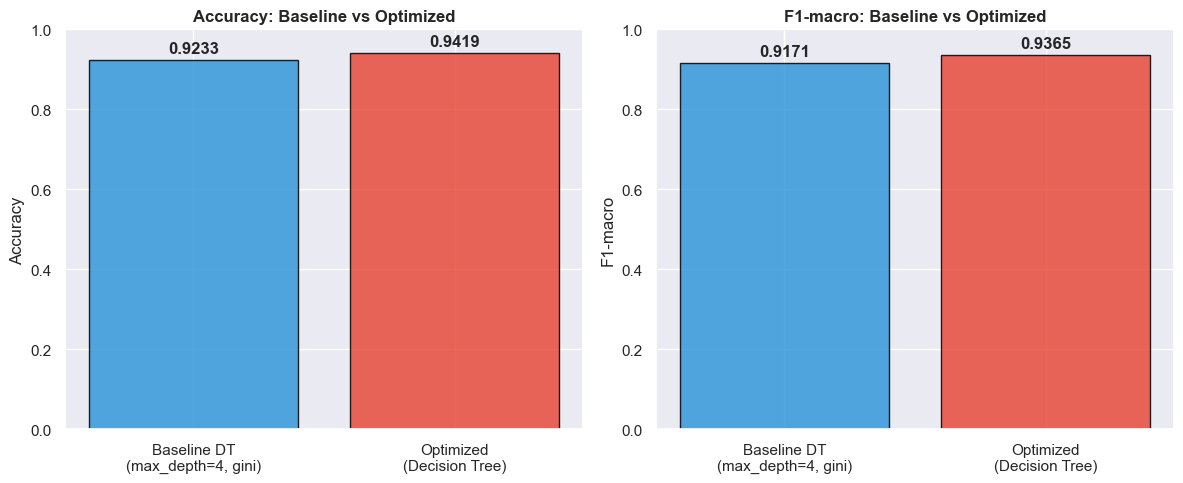


Phân tích hoàn tất!


In [26]:
# So sánh Baseline vs Optimized
comparison = pd.DataFrame({
    'Model': ['Baseline DT\n(max_depth=4, gini)', f'Optimized\n({best_tree_name})'],
    'Accuracy': [acc_baseline, acc_final],
    'F1-macro': [f1_baseline, f1_final]
})

print("                      EXPERIMENT SUMMARY")
print(f"  1. Best Criterion : {best_criterion}")
print(f"  2. Best Sampling  : {best_sampling}")
print(f"  3. Best Model     : {best_tree_name}")
print(f"  4. Best Features  : {best_k}/{n_total}")
print(f"\n  Baseline  → Accuracy: {acc_baseline:.4f}  |  F1-macro: {f1_baseline:.4f}")
print(f"  Optimized → Accuracy: {acc_final:.4f}  |  F1-macro: {f1_final:.4f}")
print(f"\n  Cải thiện → Accuracy: +{(acc_final-acc_baseline)*100:.2f}%  |  F1-macro: +{(f1_final-f1_baseline)*100:.2f}%")
print(f"\n  Best Hyperparameters:")
for k, v in grid.best_params_.items():
    print(f"    - {k}: {v}")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#e74c3c']

ax[0].bar(comparison['Model'], comparison['Accuracy'], color=colors, alpha=0.85, edgecolor='black')
ax[0].set_title('Accuracy: Baseline vs Optimized', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0, 1)
for i, v in enumerate(comparison['Accuracy']):
    ax[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

ax[1].bar(comparison['Model'], comparison['F1-macro'], color=colors, alpha=0.85, edgecolor='black')
ax[1].set_title('F1-macro: Baseline vs Optimized', fontsize=12, fontweight='bold')
ax[1].set_ylabel('F1-macro')
ax[1].set_ylim(0, 1)
for i, v in enumerate(comparison['F1-macro']):
    ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPhân tích hoàn tất!")
